In [5]:
#-----------  imports
import os
from pathlib import Path
import sys

# data
import numpy as np
import pandas as pd
import xarray as xr
import csv
import netCDF4 as nc

# plots
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
import cmocean

# image processing
from skimage import feature, filters
import cv2

# ML
from skfda.ml.clustering import KMeans
from skfda.representation import FDataGrid
from scipy.stats import gaussian_kde
    
import re
import gc
import pywt
import mat73

In [6]:
path_2018 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2018.nc"
path_2021 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2021.nc"
path_2022 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2022.nc"
path_2023 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2023.nc"
path_2026 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2026.nc"
path_2021_transect = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2021_transect.nc"
path_out = "/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute"
path_bathy = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/env/GLO-MFC_001_030_mask_bathy.nc"
path_2021_brut = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/LOCEAN_SOOP-BA_A_20210122T143044Z_MARIONDUFRESNE_FV02_EchointegrationAcoustic-18-38-70-120-200_END-20210307T041919Z_C-20260609T160140Z.nc"

In [7]:
def create_path_figure(folder_comp, title, path_in=path_2021_transect, path_out=path_out) : 
    dataset_name = Path(path_in).stem
    save_dir = Path(path_out) / folder_comp
    save_dir.mkdir(parents=True, exist_ok=True)
    path = os.path.join(save_dir, f"{dataset_name}_{title}.png")
    return path

In [3]:
with xr.open_dataset(path_2018) as ds : 
    print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:               (channel: 5, time: 154469, depth: 493)
Coordinates:
  * channel               (channel) float64 40B 18.0 38.0 70.0 120.0 200.0
  * time                  (time) datetime64[ns] 1MB 2018-01-09T12:24:46.53469...
    latitude              (time) float64 1MB ...
    longitude             (time) float64 1MB ...
  * depth                 (depth) float64 4kB 15.0 17.0 19.0 ... 997.0 999.0
Data variables:
    Sv                    (channel, time, depth) float32 2GB ...
    instrument_frequency  (channel) float64 40B ...
    day                   (time) int8 154kB ...
Attributes: (12/86)
    convention_name:                      A metadata convention for processed...
    convention_author:                    ICES WGFAST Topic Group, TG-AcMeta
    convention_year:                      2016
    convention_organisation:              International Council for the Sea (...
    convention_publisher:                 The Series of ICES Survey Protocols

# Statistiques de base : Dates, Nb_jours de données, nb_pings, (par date, nuit, jour, par heure par jour), fréquences présentes, ecart inter-pings

In [6]:
ds = xr.open_dataset(path_2026)
sv = ds["Sv"].values
day = ds["day"].values
freqs = ds["instrument_frequency"].values
time = ds["time"].values
depth = ds["depth"].values
print(f"nombre de pings total {sv.shape[1]}")
print(f"Nombre de pings jour : {sv[:, day==3, :].shape[1]}")
print(f"Nombre de pings nuit : {sv[:, day==1, :].shape[1]}")
print (f"Fréquences présentes : {freqs}")
print(np.unique(pd.to_datetime(time).date))
print(np.unique(pd.to_datetime(time).date).shape)
ds.close()


nombre de pings total 9553
Nombre de pings jour : 4038
Nombre de pings nuit : 1426
Fréquences présentes : [ 18.  38.  70. 120. 200.]
[datetime.date(2026, 1, 20) datetime.date(2026, 1, 21)
 datetime.date(2026, 1, 22) datetime.date(2026, 1, 23)
 datetime.date(2026, 1, 24) datetime.date(2026, 1, 25)]
(6,)


In [12]:
def plot_pings_per_day(path_in=path_2021, save=False):
    ds = xr.open_dataset(path_in)
    pings_per_day = (
        pd.Series(ds.time.values)
        .dt.floor('D')
        .value_counts()
        .sort_index()
    )
    ds.close()
    dataset_name = Path(path_in).stem

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(pings_per_day.index, pings_per_day.values, width=0.8)
    ax.set_xlabel("Date")
    ax.set_ylabel("Nombre de pings")
    ax.set_title(f"{dataset_name} - Nombre de pings par jour")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save : 
        path = create_path_figure("", "pings_per_day", path_in=path_in)
        print(path)
        plt.savefig(path)
    else : 
        plt.show()

/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/Echointegration2021_transect_pings_per_day.png


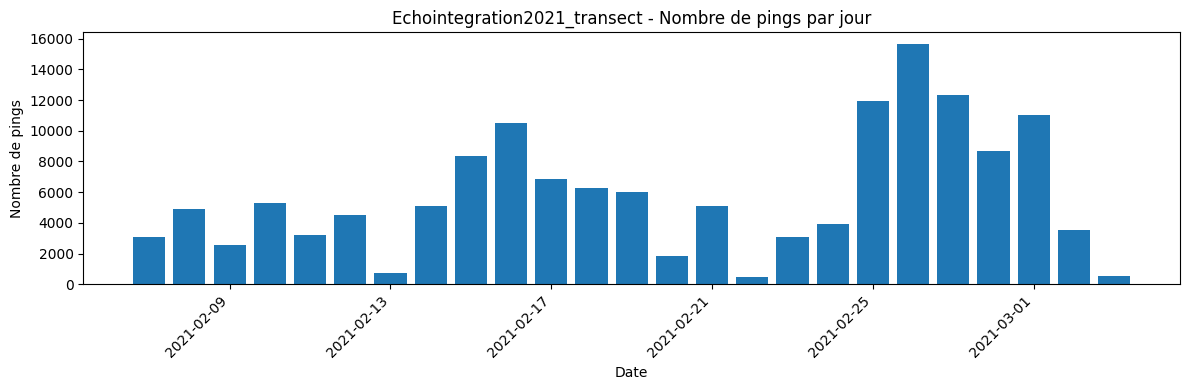

In [13]:
plot_pings_per_day(path_in=path_2021_transect, save=True)

In [4]:
def plot_hourly_distribution(path_in=path_2021, save=False):
    ds = xr.open_dataset(path_in)

    time_all = pd.DatetimeIndex(ds["time"].values)
    ds.close()
    dates = np.unique(time_all.date)
    for date in dates : 
        mask     = (time_all.date == date)
        time_day = time_all[mask]

        if len(time_day) == 0:
            print(f"⚠  Aucun ping trouvé pour la date {date}.", file=sys.stderr)
            available = pd.DatetimeIndex(np.unique(time_all.normalize()))
            print(f"   Dates disponibles : {available.date.tolist()}", file=sys.stderr)
            return

        hours  = time_day.hour
        counts = np.bincount(hours, minlength=24)

        dataset_name = Path(path_in).stem
        print(dataset_name)
        fig, ax = plt.subplots(figsize=(13, 5))

        ax.bar(np.arange(24), counts, width=0.8)

        ax.set_xlim(-0.6, 23.6)
        ax.set_xticks(np.arange(24))
        ax.set_xticklabels([f"{h:02d}h" for h in range(24)], fontsize=8.5)
        ax.set_xlabel("Heure de la journée (UTC)")
        ax.set_ylabel("Nombre de pings")
        ax.set_title(f"{dataset_name} - Distribution des pings par heure — {date} ({len(time_day):,} pings)")
        ax.grid(True, axis="y")
        plt.tight_layout()

        if save:
            path = create_path_figure(f"n_pings_per_date/{dataset_name}", f"hourly_{date}", path_in=path_in)
            print(path)
            plt.savefig(path)
            plt.close()
        else:
            plt.show()

In [11]:
plot_hourly_distribution(path_in=path_2021_transect, save=True)

Echointegration2021_transect
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/n_pings_per_date/Echointegration2021_transect/Echointegration2021_transect_hourly_2021-02-07.png
Echointegration2021_transect
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/n_pings_per_date/Echointegration2021_transect/Echointegration2021_transect_hourly_2021-02-08.png
Echointegration2021_transect
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/n_pings_per_date/Echointegration2021_transect/Echointegration2021_transect_hourly_2021-02-09.png
Echointegration2021_transect
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/n_pings_per_date/Echointegration2021_transect/Echointegration2021_transect_hourly_2021-02-10.png
Echointegration2021_transect
/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/n_pings_per_date/Echointegration2021_transect/Echointegration2021_transect_ho

In [14]:
def plot_ping_intervals(path_in, save=False):
    ds = xr.open_dataset(path_in)
    time = pd.DatetimeIndex(ds["time"].values)
    ds.close()
    if len(time) < 2:
        print("⚠  Moins de 2 pings : impossible de calculer les écarts.", file=sys.stderr)
        return
    deltas_s = np.diff(time).astype("timedelta64[ms]").astype(float) / 1000.0
    t_mid    = time[:-1] + (time[1:] - time[:-1]) / 2
    # Masque : paire de pings appartenant à la même journée
    same_day = (time[:-1].normalize() == time[1:].normalize())
    deltas_same = deltas_s[same_day]
    t_mid_same  = t_mid[same_day]
    mean_dt    = np.nanmean(deltas_same)
    med_dt     = np.nanmedian(deltas_same)
    std_dt     = np.nanstd(deltas_same)
    n_outliers = int(np.sum(deltas_same > mean_dt + 3 * std_dt))
    dataset_name = Path(path_in).stem
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [3, 1]})
    ax = axes[0]
    ax.scatter(t_mid_same, deltas_same, s=1.5, alpha=0.5, linewidths=0)
    ax.axhline(mean_dt, lw=1.5, linestyle="--", label=f"Moyenne  {mean_dt:.2f} s")
    ax.axhline(med_dt,  lw=1.2, linestyle=":",  label=f"Médiane  {med_dt:.2f} s")
    if n_outliers:
        ax.annotate(f"{n_outliers} outlier(s) > μ+3σ",
                    xy=(0.99, 0.94), xycoords="axes fraction", ha="right", fontsize=9)
    ax.set_title(f"{dataset_name} - Écart inter-pings (même journée uniquement)")
    ax.set_ylabel("Δt (secondes)")
    ax.set_ylim(0, 1000)  # ← axe Y limité à [0, 1000]
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate(rotation=25, ha="right")
    ax.grid(True, axis="both")
    ax.legend()
    ax2 = axes[1]
    bins = np.linspace(0, 1000, 80)  # ← bins calés sur [0, 1000]
    ax2.hist(deltas_same, bins=bins)
    ax2.axvline(mean_dt, lw=1.5, linestyle="--")
    ax2.axvline(med_dt,  lw=1.2, linestyle=":")
    ax2.set_xlabel("Δt (secondes)")
    ax2.set_ylabel("Fréquence")
    ax2.set_xlim(0, 1000)  # ← axe X limité à [0, 1000]
    ax2.set_title("Distribution des écarts intra-journée (percentile 99)")
    ax2.grid(True, axis="y")
    plt.tight_layout(h_pad=2)
    if save:
        path = create_path_figure("ping_intervals", "ping_intervals", path_in=path_in)
        print(path)
        plt.savefig(path)
    else:
        plt.show()

/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/ping_intervals/Echointegration2026_ping_intervals.png


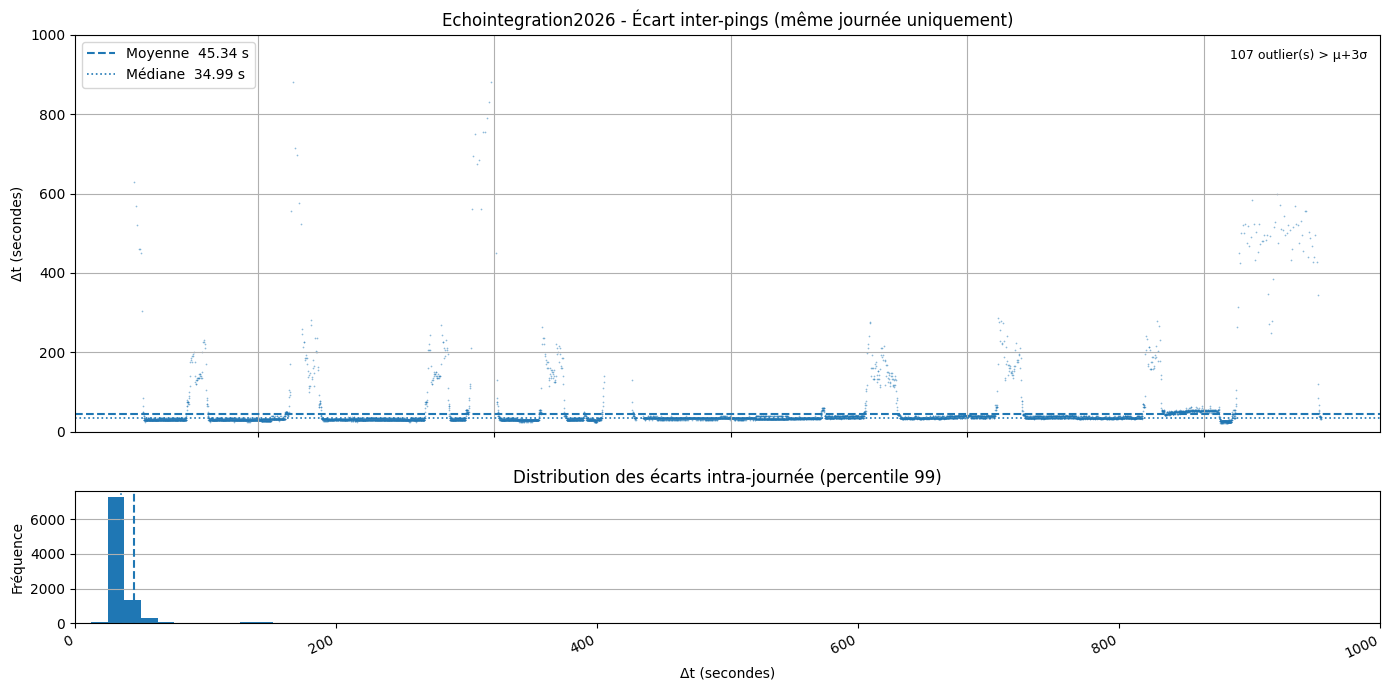

In [20]:
plot_ping_intervals(path_2026, save=True)

In [8]:
def plot_sv_nan_depth(path_in, save=False):
    ds = xr.open_dataset(path_in)
    sv    = ds["Sv"].values      # (n_freq, n_ping, n_depth)
    depth = ds["depth"].values   # (n_depth,)
    time  = ds["time"].values    # (n_ping,)
    freqs = ds["channel"].values # (n_freq,) en kHz
    ds.close()

    dataset_name = Path(path_in).stem

    # Pour chaque (freq, ping) : profondeur du dernier Sv non-NaN
    valid = ~np.isnan(sv)                      # (n_freq, n_ping, n_depth)
    last_valid_idx = (valid.shape[2] - 1) - np.argmax(valid[:, :, ::-1], axis=2)
    all_nan = ~valid.any(axis=2)               # True si toute la colonne est NaN
    nan_depth = depth[last_valid_idx].astype(float)
    nan_depth[all_nan] = np.nan

    fig, axes = plt.subplots(len(freqs), 1, figsize=(14, 3 * len(freqs)), sharex=True)
    if len(freqs) == 1:
        axes = [axes]

    for ax, freq, nd in zip(axes, freqs, nan_depth):
        mean_d = np.nanmean(nd)
        ax.scatter(time, nd, s=1, alpha=0.4, linewidths=0)
        ax.axhline(mean_d, color='r', lw=1.5, linestyle='--', label=f"Moyenne {mean_d:.1f} m")
        ax.legend(fontsize=9)
        ax.set_ylabel("Profondeur (m)")
        ax.set_title(f"{dataset_name} - {int(freq)} kHz — dernière profondeur Sv valide")
        ax.invert_yaxis()
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.grid(True)

    fig.autofmt_xdate(rotation=45, ha='right')
    plt.tight_layout()

    if save:
        path = create_path_figure("sv_nan_depth", "sv_nan_depth", path_in=path_in)
        print(path)
        plt.savefig(path)
    else:
        plt.show()

/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/sv_nan_depth/Echointegration2021_transect_sv_nan_depth.png


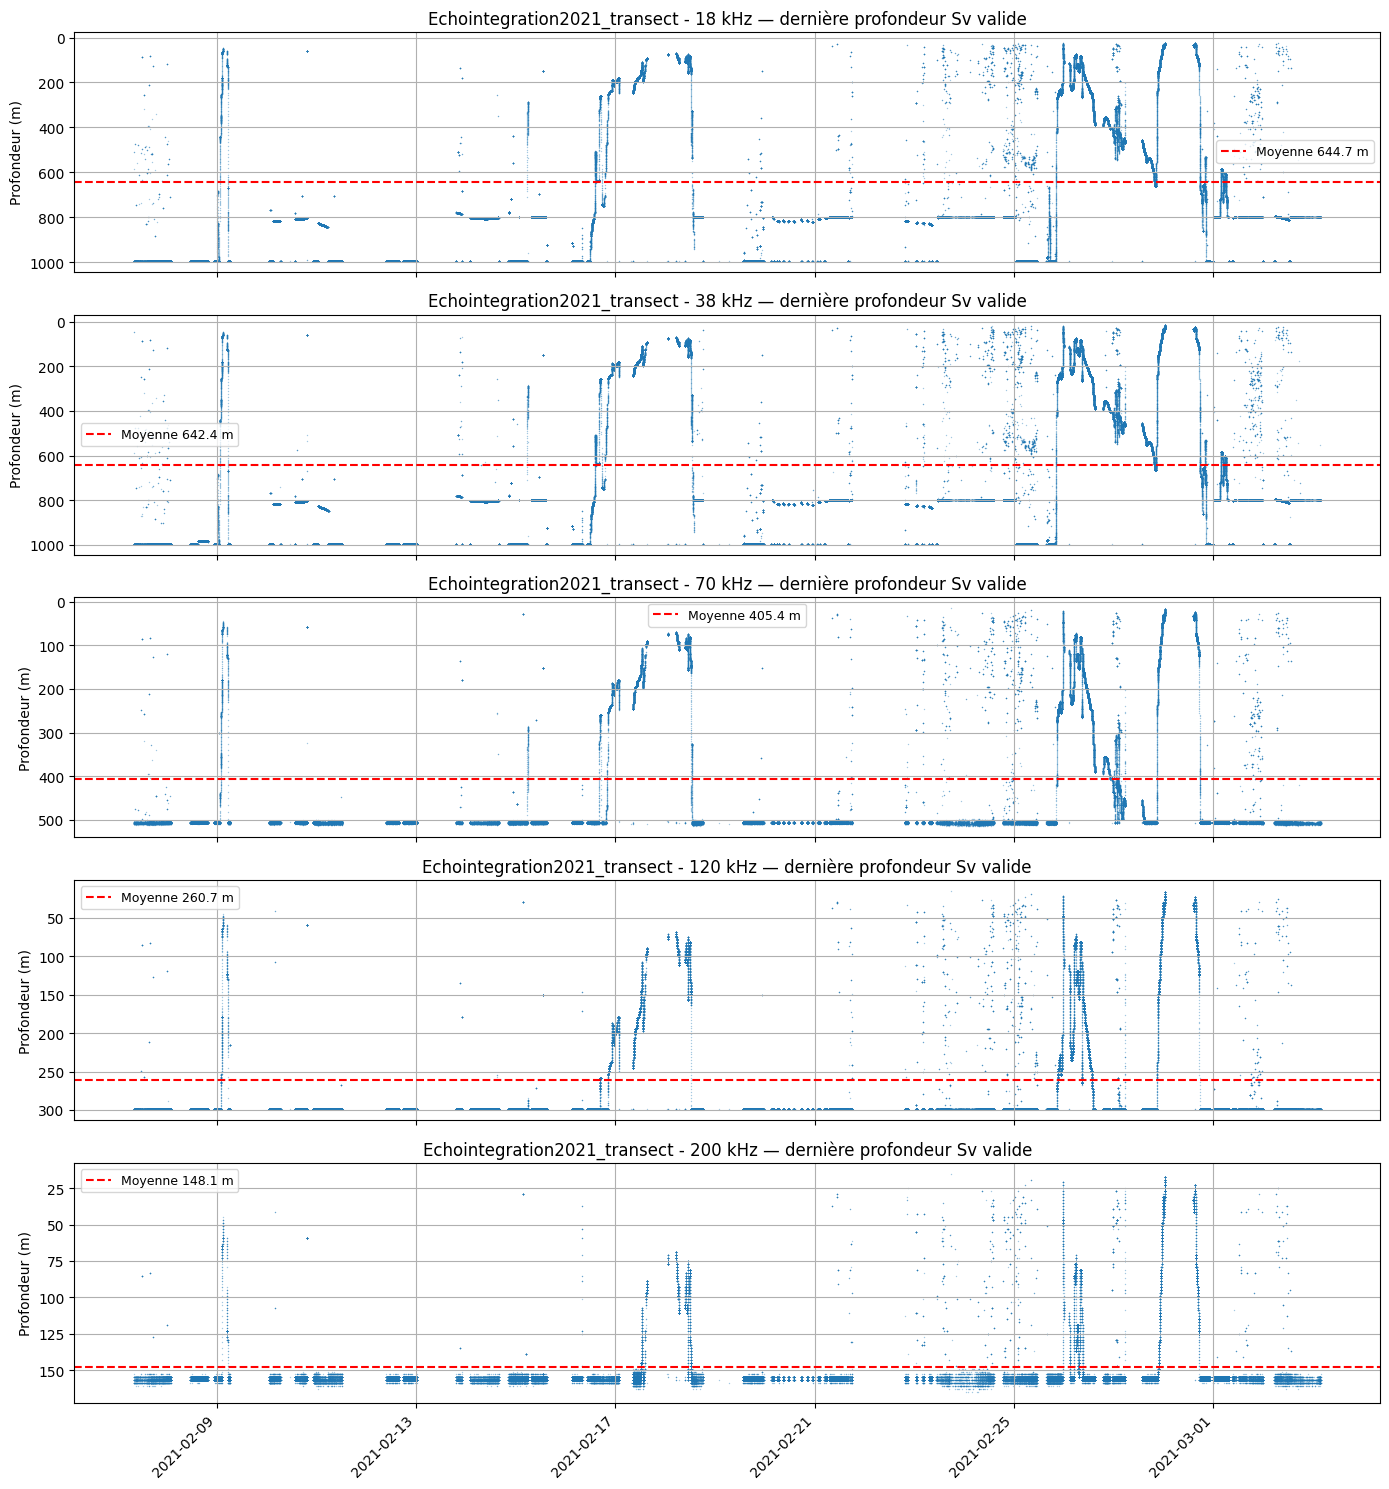

In [11]:
# for path in [path_2018, path_2021, path_2022, path_2023, path_2026] : 
#     plot_sv_nan_depth(path, save=True)

plot_sv_nan_depth(path_2021_transect, save=True)

In [21]:
def plot_pings_per_day_multi(path_2018, path_2021, path_2021_transect, path_2022, path_2023, path_2026, save=False):
    paths = {
        2018: path_2018,
        2021: path_2021,
        20211 : path_2021_transect,
        2022: path_2022,
        2023: path_2023,
        2026: path_2026,
    }
    colors = {
        2018: "tab:blue",
        2021: "tab:orange",
        20211 : "tab:cyan",
        2022: "tab:green",
        2023: "tab:red",
        2026: "tab:purple",
    }

    fig, ax = plt.subplots(figsize=(14, 5))

    for year, path in paths.items():
        ds = xr.open_dataset(path)
        pings_per_day = (
            pd.Series(ds.time.values)
            .dt.floor('D')
            .value_counts()
            .sort_index()
        )
        ds.close()

        # Ramener toutes les dates sur la même année (2000) pour superposer
        dates_normalized = pings_per_day.index.map(
            lambda d: d.replace(year=2000)
        )

        ax.plot(dates_normalized, pings_per_day.values,
                color=colors[year], lw=1, alpha=0.7)
        ax.scatter(dates_normalized, pings_per_day.values,
                   color=colors[year], s=15, alpha=0.8, label=str(year), linewidths=0)

    ax.set_xlabel("Date (jour/mois)")
    ax.set_ylabel("Nombre de pings (échelle log)")
    ax.set_title("Nombre de pings par jour — comparaison inter-annuelle")
    ax.set_yscale("log")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.legend(title="Année", framealpha=0.9)
    ax.grid(True, alpha=0.3, which="both")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if save:
        path = create_path_figure("", "pings_per_day_multi")
        print(path)
        plt.savefig(path)
    else:
        plt.show()

/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/Echointegration2021_transect_pings_per_day_multi.png


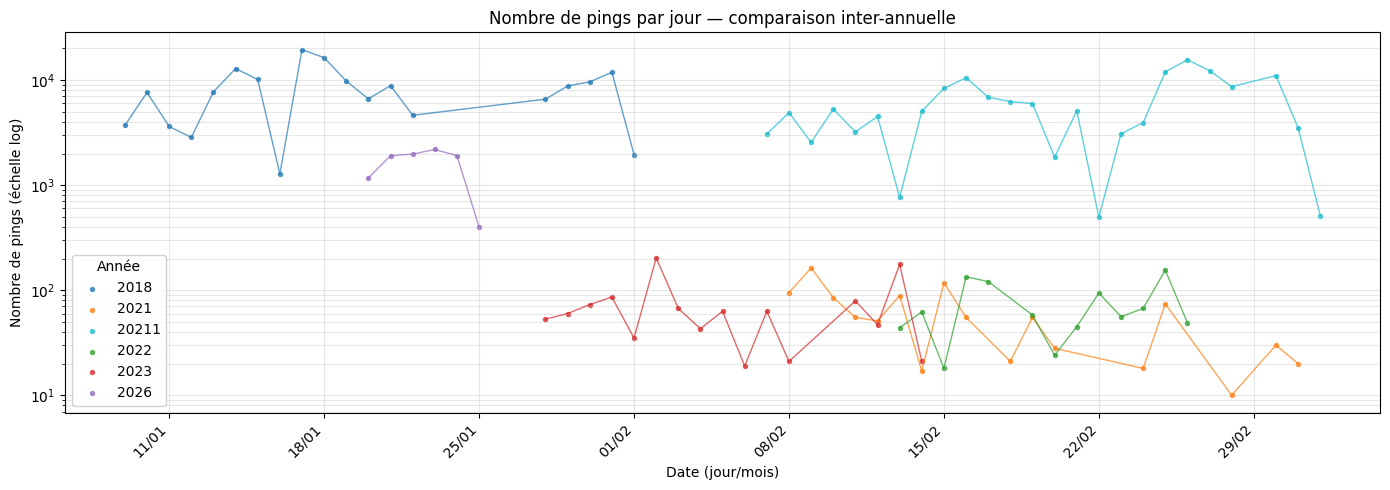

In [22]:
plot_pings_per_day_multi(path_2018, path_2021, path_2021_transect, path_2022, path_2023, path_2026, save=True)

In [23]:
def display_traj_multi(path_2018, path_2021, path_2021_transect, path_2022, path_2023, path_2026,
                       path_bathy=path_bathy, save=False):

    paths = {
        2018: path_2018,
        2021: path_2021,
        20211 : path_2021_transect,
        2022: path_2022,
        2023: path_2023,
        2026: path_2026,
    }
    colors = {
        2018: "tab:blue",
        2021: "tab:orange",
        20211 : "tab:cyan",
        2022: "tab:green",
        2023: "tab:red",
        2026: "tab:purple",
    }

    # --- Figure ---
    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.coastlines()

    # --- Bathymétrie ---
    bathy = xr.open_dataset(path_bathy)
    lon_b = bathy['longitude'].values
    lat_b = bathy['latitude'].values
    depth = bathy['deptho'].values
    bathy.close()

    bathy_plot = ax.contourf(
        lon_b, lat_b, depth,
        levels=20,
        cmap='Blues_r',
        transform=ccrs.PlateCarree(),
        zorder=0
    )
    plt.colorbar(bathy_plot, ax=ax, label='Profondeur (m)', shrink=0.5)

    # --- Grille lon/lat ---
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5, color='black', alpha=0.5, linestyle='--'
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    ax.text(0.5, -0.05, "Longitude (°)", transform=ax.transAxes,
            ha='center', va='top', fontsize=10)
    ax.text(-0.07, 0.5, "Latitude (°)", transform=ax.transAxes,
            ha='right', va='center', rotation=90, fontsize=10)

    # --- Trajectoires ---
    for year, path in paths.items():
        ds   = xr.open_dataset(path)
        lons = ds['longitude'].values
        lats = ds['latitude'].values
        ds.close()

        # Filtre géographique : lat < -40°S et lon > 50°E
        mask = (lats < -40) & (lons > 50) & (lats > -60) & (lons<80)
        lons_f = lons[mask]
        lats_f = lats[mask]

        if len(lons_f) == 0:
            continue

        ax.scatter(
            lons_f, lats_f,
            color=colors[year],
            s=2, alpha=0.7,
            transform=ccrs.PlateCarree(),
            label=str(year),
            zorder=5,
        )

    # --- Extent : union de toutes les trajectoires filtrées ---
    ax.set_extent([50, 80, -60, -40], crs=ccrs.PlateCarree())

    ax.legend(
        markerscale=5,
        fontsize=9,
        title="Année",
        title_fontsize=10,
        framealpha=0.8,
        loc='lower right',
    )
    ax.set_title("Trajectoires inter-annuelles")

    if save:
        path = create_path_figure("", "traj_bathy_multi")
        print(path)
        plt.savefig(path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [24]:
display_traj_multi(path_2018, path_2021, path_2021_transect, path_2022, path_2023, path_2026, save=True)

/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/Echointegration2021_transect_traj_bathy_multi.png
